Found: 25000 cats, 25000 dogs
(1000, 224, 224, 3)


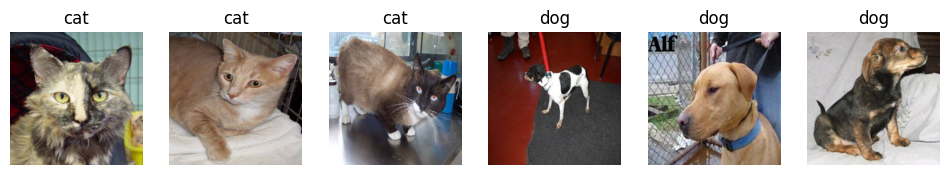

(1000, 150528)
1    529
0    471
Name: count, dtype: int64
true     cat  dog
cluster          
0        230  241
1        270  259
Cluster mapping: {0: 'dog', 1: 'cat'}
Accuracy: 51.10%


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans

# Point this at the dataset (not a notebook). Add the dataset via "Add Input" first.
DATA_DIR = "/kaggle/input/notebooks/sachinpatil1280/cats-vs-dogs-image-classification-using-cnn-95"
IMG_SIZE = (224, 224)
SAMPLE_SIZE = 500  # per class
EXTS = (".jpg", ".jpeg", ".png")

# Find every image under DATA_DIR and label it as cat/dog from its path or filename
cat_paths, dog_paths = [], []
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if not f.lower().endswith(EXTS):
            continue
        full = os.path.join(root, f)
        key = (os.path.basename(root) + "/" + f).lower()
        if "cat" in key and "dog" not in key:
            cat_paths.append(full)
        elif "dog" in key and "cat" not in key:
            dog_paths.append(full)

print("Found:", len(cat_paths), "cats,", len(dog_paths), "dogs")
assert cat_paths and dog_paths, "No images found. Check DATA_DIR / that the dataset is added."

def load_images(paths, label, n):
    data, labels = [], []
    for p in sorted(paths)[:n]:
        try:
            img = Image.open(p).convert("RGB").resize(IMG_SIZE)
        except Exception:
            continue  # skip unreadable files
        data.append(np.array(img))
        labels.append(label)
    return data, labels

cat_imgs, cat_labels = load_images(cat_paths, "cat", SAMPLE_SIZE)
dog_imgs, dog_labels = load_images(dog_paths, "dog", SAMPLE_SIZE)

images = np.array(cat_imgs + dog_imgs)
true_labels = np.array(cat_labels + dog_labels)
print(images.shape)


# VISUALIZATION
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
idxs = np.linspace(0, len(images) - 1, 6, dtype=int)
for ax, idx in zip(axes, idxs):
    ax.imshow(images[idx])
    ax.set_title(true_labels[idx])
    ax.axis("off")
plt.show()

# PREPROCESSING
X = images.reshape(len(images), -1) / 255.0
print(X.shape)

# TRAINING
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

# TESTING
predicted_clusters = kmeans.predict(X)
print(pd.Series(predicted_clusters).value_counts())

# VALIDATION
print(pd.crosstab(predicted_clusters, true_labels,
                  rownames=["cluster"], colnames=["true"]))

# ACCURACY
pred_a = np.where(predicted_clusters == 0, "cat", "dog")
pred_b = np.where(predicted_clusters == 0, "dog", "cat")
acc_a = (pred_a == true_labels).mean()
acc_b = (pred_b == true_labels).mean()

if acc_a >= acc_b:
    accuracy, mapping = acc_a, {0: "cat", 1: "dog"}
else:
    accuracy, mapping = acc_b, {0: "dog", 1: "cat"}

print(f"Cluster mapping: {mapping}")
print(f"Accuracy: {accuracy * 100:.2f}%")
